On réalise nos imports

In [152]:
import pandas as pd
import urllib
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import json
import unidecode
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import datetime

On charge nos données en mémoire

In [153]:
customers = pd.read_csv('data/olist_customers_dataset.csv')
geolocation = pd.read_csv('data/olist_geolocation_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')

Première étape : On regarde 5 exemples de customers
Deuxième étape : On vérifie la moyenne de valeurs NaN

In [154]:
print(customers.sample(5))
print(customers.isna().mean())

                            customer_id                customer_unique_id  \
82104  97ef4e6c5876d3a99800f0314cb2a717  210027da3c19d3fb87969b633244f1d8   
43341  c009189a0fce48a8844dd35feca6025e  81f5afe83c873351c6089ce0ded7dc2e   
12309  5dff24d9f9695d450bedd739eae31bb4  cc68db9bd735565d39c8ffd3941ed347   
51862  f17f59d0945b9f7768af23f2b9685555  17eca8f3dae2fcda526c3c45edf44f0c   
64936  45bbf2eff4f2ac65e54fadd264cddd18  a4b405a47666e60990bc6f5dbf5aae65   

       customer_zip_code_prefix   customer_city customer_state  
82104                     65062        sao luis             MA  
43341                     31015  belo horizonte             MG  
12309                      7240       guarulhos             SP  
51862                     20550  rio de janeiro             RJ  
64936                     27600         valenca             RJ  
customer_id                 0.0
customer_unique_id          0.0
customer_zip_code_prefix    0.0
customer_city               0.0
customer_state     

On voit que les résultats sont assez propre, vérifions pour la géolocalisation des clients

Première étape : On récupère 5 exemples
Deuxième étape : On récupère la moyenne de NaN
Dernière étape : On vérifie les valeurs unique (les même villes)

In [155]:
print(geolocation.sample(5))
print(geolocation.isna().mean())
print(geolocation['geolocation_city'].unique())

        geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
468552                        23904       -23.005691       -44.311894   
45062                          3102       -23.545523       -46.597363   
882172                        85940       -24.574887       -53.980367   
913396                        88330       -27.003918       -48.620114   
343901                        14806       -21.745529       -48.158116   

          geolocation_city geolocation_state  
468552      angra dos reis                RJ  
45062            sao paulo                SP  
882172       quatro pontes                PR  
913396  balneario camboriu                SC  
343901          araraquara                SP  
geolocation_zip_code_prefix    0.0
geolocation_lat                0.0
geolocation_lng                0.0
geolocation_city               0.0
geolocation_state              0.0
dtype: float64
['sao paulo' 'são paulo' 'sao bernardo do campo' ... 'ciríaco' 'estação'
 'vila lângaro']

C'est assez propre par contre, le nom des villes pourrait devenir problématique, il faudra donc le traiter

In [156]:
def format_string(column):
    return unidecode.unidecode(' '.join(column.split()).lower())

geolocation['geolocation_city'] = geolocation['geolocation_city'].apply(format_string) 

geolocation[geolocation['geolocation_zip_code_prefix'] == 87020].head()    

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
892110,87020,-23.408702,-51.940975,maringa,PR
892118,87020,-23.412878,-51.944784,maringa,PR
892146,87020,-23.414812,-51.939946,maringa,PR
892164,87020,-23.413211,-51.943328,maringa,PR
892175,87020,-23.417458,-51.939589,maringa,PR


On voit que notre fonction a réussis à remettre toute les villes dans un format correcte 

Par contre nous remarquons qu'ils existent plus d'un code postal pour un même emplacement, ce qui ne paraît pas logique, nous allons ainsi réinitialiser l'index avec la médiane de la longitude et de la latitude pour régler le problème et émettre une carte pour mieux comprendre les villes des clients

In [157]:
def reset_longitude_latitude():
    other = geolocation.groupby(['geolocation_zip_code_prefix'])['geolocation_state'].nunique().reset_index(name='count')
    other[other['count'] >= 2].shape
    state_max = geolocation.groupby(['geolocation_zip_code_prefix','geolocation_state']).size().reset_index(name='count').drop_duplicates(subset = 'geolocation_zip_code_prefix').drop('count',axis=1)
    silver_geo = geolocation.groupby(['geolocation_zip_code_prefix','geolocation_city','geolocation_state'])[['geolocation_lat','geolocation_lng']].median().reset_index()
    silver_geo = silver_geo.merge(state_max,on=['geolocation_zip_code_prefix','geolocation_state'],how='inner')
    silver_custom = customers.merge(silver_geo, left_on='customer_zip_code_prefix',right_on='geolocation_zip_code_prefix',how='inner')
    return silver_custom
    
def plot_brasil_map(data):
    brazil = mpimg.imread(urllib.request.urlopen('data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAOQAAADdCAMAAACc/C7aAAAAkFBMVEX////BwcHExMT6+vq/v7/4+PjGxsb19fWioaCnpqXt7e2ysbCrqqny8vLs7Ozk5OTQz8+dnJvW1tXe3d2wr666ubjg39+WlZTMy8tycG6FhIKLioiXlpWQj459e3q2tbV4d3VmZGJBPzxZV1U+OzgAAABhX11NS0gtKSVzcXBLSEUUDQAhHxocGBI0MC1TUU84ZWfrAAAWq0lEQVR4nN1dh5qbOLsGSYgmEIhiDKZ4Juvs5N+T3P/dHQmMTRHFjD325H12k4wLo4+vFwlFuSuAlyT4vpd8PViRovz1RGLG/4fPXsVjQRzlL+cktW1BYxyxm74G3ccs5/OASBu8EnteK6aWesulYkTvs6a7A5aJZ+jtD5GP1bDDEHDLpRhkL8tLbl4Qw4HN2eBTpb9Maq6/Dk0U3bvz2u4GjbjQU+yAUGfEOOasvoxeciH39OUPPglBUP/ljTQwWU+jEtWXeF0isTXxBpt6Y4yglvNXJnLqjfXGlfkLl3o62IQ/1NbbkVabb/I5X4tY7uCi9X7POP+N7rCaBwEm0pfnZK8fQuD2dgS3BUlfCYfIX5aKK0xcRQch7JAD7cu/wjsv7Y6AGBOJu4hk1hXHscqpNwtLUEd51gk7rsaWfOMJMKWxl+6jMUUwknxSbbxqxECpmi6DCHXdqbd7ulrGCkMSW6qhCED3YAzF0+0JH0OBAj12Ni78Mvowthf4SJ4UpmuOo3Nolily4WTESrdhjnIcfq9DpOZZCrYTneGzu8gSJkuq3WNqPCXZJnHg1WiIGegND9CbQMUbmVPr7ONjGHljBrE3OdOg3I49FkMPofbFLMzP2qj7o6/SnP/B0gBJFdl6t2PZ64bsxQdjRKR1tTEaNmjQ/pAEyhBxYsbRdJoIs1Ly6u72NX4eUdITNspwu2yWdG2qI1uxPWtIoMRnMNllHg+oDWyqMEAeUNnAR8jkbEHBsqFJ1sPqObkI1dzBWhji1iYbxtNEYheXrIg9iCK8g8y7Pho6IpEnDbZH7n8DJxW9TxP78J9hXCdyDBkiSWy3FI3aPXGAJkoT+vXxwA2/Evc+Whgc5n7hO06X/dD8ZUZRkH952e4GIt2u6J1XSpbMSNlhP4GQRElJwFdTeYO4Kh2n75wJDpYibu2ig9aRGy734BeE7CL7pqLtp8HWlzE6+aB95qC1HL+cq7N1eCQuolOPOlbMIuMLGaqvzvJqpsC04lyo2tcKWbLRw6FmmnMYfRBG2He+ymuuDUHMjP/h8BD24MFLIGuMg70hamZLPQeu3t5+ll/CUGmKL0EgFmoIHf5fejUnOF/6HhOiMiXWGPz4c8zo4wldW3qJd4Hij5Zjukul9GNggXEOcwV5++9EHu0+11u6vXIYv2gYC1U4i+0WPsGq078/HspNuL6yzfxC8qqVL1qfJVQY/d8vL91/+kJTsOZEaQhpHqzZny02CpU1/pQ/9o+yts4dar5sUWZnQcRNYj+U5N9lY70N9IYe3AyOn2iyNq15nynp7wdpplQCb4dmxGr4vu27YS2lDtfI7Ib29S24l4S4NttYv9ldQv+DSRSoJDhc3/xch/ulsXijrzMvCuOS8PAWvf0DI3Rf7bxf23BjtTG8Ol9WmH6Wi/YX9UL1gO7WVrgbke7GJXXuTfxu7FszrYfsX3NnWW5g+D+JEXym9O7erWt4i7/tokMk+uhbVzPyfxF2EvR55BPt+LsNEdGNi/CuRsH71ddEdFSUD105qyyqNsccdxP7jcbf7XxP7ZXzmcetrt5VdLZ1sfeaycAbdTuf8hZpLjJd7a37mppu+h03hOfz2KiR+lTOnpy59t6X0WpLm+FeRKobfWQ5xchWTIMB85wbFVPTnLvNSW30kXiqbVC2Wa5zHPgOcINi6hpI2CG6U2/C2+aIpluy18SVDWds2DrhowEy8wMVadadqg4bGTlsCF1xLSORUaJO10hsbFrWfVv3U8NpC5jpGPjtAt1wLGyuIZ+g6gAsfuJmmFvuWeDPZHlX9hGJSMNwvjBFHzHHt0Wzg1nVKi+cKMZ1JccIIqNSIJz4xf4jBjI31BNhmI5boB1c5/ijcSjVWACTEJKExrgDED9kiG+D2XmzPZLP3PBrSuMWo8JKj+xspNgPmfuiG3pUCd5ThU7eHVZd/50OGUN6lUttOEb1GCI3mR0lsWfipG6YAwYfCgacNQbV2ofMgW9MljN9hshuJBwPvMFhIJ9qn+j1bbpbkG37WqXMbBPadajv30Qqek6UsSu7kn79zH1E7ZZuu3Ol0DRn6gZpVYddXUep5VRIulc3Rhty1Kwvn/g+heQetuVYgSGWMr3hqztr0jVP9FQGe9aMgqlprrpUSfwu73S02Ey8HUMNWQermRsZ2pTmPWHHureu7HAKWYmvN71SxWQQI0COPzusdretZx7aFmF1i/PcocTwOH5EkOF333CM7BI3NFyluZH78NRYdYg6a6g2LGcZW0o712786C144n+MmHH5XNAyzdfh/hxLeODqcOLsIX0xmN3uJds1D2cUFRjlUttYXf51Gr/J8PHiZIIoMh7Rs5YM4S/gMlYzLLMGE3MWNAtglNQ381ywC4rLb40jZLZExiI6UldMa9yKYGn2bIjOPNB7VwoCeyrK2zPPToJC1LCaqqVhu/nZ/MJi95G3RJ4LHZ5pmPZde0a5d2NnEnaqNun1nyiZbKaf9T4NuNewAiX2meK3k/w7z02Ol+iWXvoqWmSYd2q9cvkhq8dHWlgdT3ZhHp2pNbZq5u2TRCWpkFgxX02zIyn0BIH0Kp9V93sgMlZ32hjAeDLR4Mb+5pZdt/sRp4c6LNvNDEWMqyvxD01RbVehuqOqIEsmP0pxmKwRXIpc6iZTAZiY9rzRjTjdz2M4M7PVQJfUzRlh4io0VjmqzhvjIRw9Wh5oKBuvZqfyWy1uHbhN9tNebYcawlrMbMkjrZPq/ZbzPhYKVDXqBSSyqI4t+BX9UmKRUynYcMPWX0XsWuv92IzElpP3qWoV7nAauYYAIVXFx97CiFSzfHOOTP8SQ7NQMbAC+6ijF+emjHIQ0dfCOlNlbj/OZXZX9KyTyxA3FggPLjjReVB9OZlcsYPOFRK/xJkd9lF7psxYzUs4UBCvVvZq4tN6pcT7+tr19kaoFSLHOtayoKsqKor0WAzNxVReBAxJDdQ2fN/rr96bKJXCcq2FDQdC36xwwnTVW/toIQxDK6rc3tgWIVRkK8lexTgxB+o8o96JMTAfzJLw3Z50/Pt1IjveKFTHA73NeHGT6lPTbAIYwvTOTfDrXY77EjPybgMVRAN7qhemYSeXdcZ9vtKSNLdrn+fI+QC5ZCQym66++0aNJEnwTCbwMXolEUPNbmcpnh37vqGpl7vmHcrOPQiaW+D52MScRnMn0RTdbY1RGQ5vPkxE5V6cC3DgGZwsu1g+jIVyhOYVBhXbM9trydJPmvQNT01vPL0NzD02fIXcQwI0IehN2qD7niv5jYmRqgEzCJFHyxumH1S7LEsimAxYLNtBY3qgR/zilgoTGmF98BF3kT8m7gX9iCzm5VQxpGIVHZsDhaS3aOuIR/PlQJXeORP3d64vBfy+q2hlpngI4NGWtxZQ1yMmZn+kvklt/aKUSPmG0NUgUuOMQiuJr1SypXSQy7aGSRQEbFRcl/zK8deRf7k1Um8j23q3Hlolf92Jw592u1468aErYKFoiGtjvluRHY+J7JycJOfZp8RVmQ4ZuFtoVkNXbDVRTJ6CAID+XTP7OPgMybPOIjzpXaKfauBOZSvaB9eRXBXhD5Ybiu6HedbvqlGelqtqViLAsjz9vO0+G9zmSvaVxxDZmKPIWNU8dVURmIP3ldbB8XhMwWx6MI2QjqaApIbQOdS+D8ebdHOihhO1tK0KDfUcuij5s6FwPx4b0eaKGmVZ3f47pnpY8Y3NeMsPQJHdp3wz3z7e0niduPnmrbPTO4J/32kqYLZys2znJZi6bYf8tlIYPKQb24Vj7GeoRFukZbIM7d8yoR8AFxd36+rAmaoxlWQoi8BT2dhulfA5YtsuEyUPdGs9ewYxmeblsHG/BlMH1VDZDjAJcESpKOqo0T2PnYB4UlnghvFaL1J0qetZqWHcc0BBI7iTaW1RhgEl0ih4w3YSL4LDuc7zG+tspRuoGAsa792egwlWSiMeXXZLpO67htzArjOucYRQuZ/Okz+JSM2HVG6ZFKA/vVSopR4lfaVaJfouVoHxlhWkeNT+Q2gbPT3YdibtXnES31F8xySN0+DioBMzjN6W5YIKbUS7/f6RR6jSyLhOXjnbxlpqOStTEcb5hc1j/X3i21PZex+qoFG1izvtEZyGdZm03TaofJ46qk9r8jJqmMRs6jnkfX4+1VKxIFEFX3FuCDSYauTWmtMFZBgZK3gWemvJlHhRTWT55yuO+7UCvixy3HY/p/sd1qJ51RJBJDp94XGU25yxOymT0+9c0BD53xce5rMlpuMyN9lIcJczSvTlRMpKxMuYca24vWuuSVRVUslKGsOzbavWNmibtgjPmeTmBmg+goo1LGU5YnqnJhLfLY1cA7LBvE5uPROozavWpImZ5iDUUYiAeQ2Navmlh6e6G4ofk2G15pt1OGCebayTpa51PUKMgjOJnMgtWexm3Ewk9MyJr8CAZrGxV9DgvNBSTO9qmu5dSPxinTwcbo2u0GSDg52Qrej7YugBA+uQZUWmdmjkSdaGxW7GylT+imnL2rSexwE61RmOVHuHn0bkrSUeJHGsVDg+a7RXoAVzPA2pgPgAg+cQeWuELqvGhdTl9sWZ6h2I5zvQSEUVqvIINYS+MpHYl0VItTsIFVrIc0nqUaY7QN2lhOz/pIYQW/z4TKuLW4icmIWyiW2XFZk6vs5yGQo8zj0OjLFZCE7ObUa8P1K9Hclayguc3dTCNE0bbLvqg6GOZU1SMWD2lS6Eo7QblO8Lwc/EsFeD2SjI7dCIuQFS1egZB6cKLNxcWM0SeZgp7sDk6jvySuik/aQHVSwc+a1V8yUqOpOaWHFHWEEd8HypSl6xsPklW0oAZwof8OIfo/3+CR6kg+4qYa9tBRc6uQJ0tMOzg1ZccWHjRmg3r/KTIO6ZshgbBBmdgv9vtliChnM00tbw4Io0scAzDopvYOzrrac0rbdvU1PoTQkUt2JscTh9fji8DVtB/gc/V1w5TBHJHtt0MTENUzN2BKJg8fh6mE/yWmMXIlXs13E63rBj6n74xWx/1EVGnEtkaaB52jZ7yGsNDwb4EPK/ds84RP0CYksCl8A0zSktclujO8Xq5Oo/QFSd0mOIQf7kZwJOZV5ssANB4+ERdfU4UYNaunelTADDPc+VUXmm0fQzjIGflU9+ZNX4QXgtcr+TLkLHQ1CcPGYciyozEjY+iLkGM0PuNv4FZ9PqC30EmyaH7okZb7hvD/KFrqsnahSpeZHn1GOBzqYK8bR2F/+Bs7SmtQH66uB8hBn/Bcz2cA5mMUyO5BA0h6hb02X4cwvrHO3wdKz+8dlEzsevpPGGuuoR7jACGntNChlM1eFxt0BnvBXoFYhc3CbKfMZDBD2pOLUreuFOl0rVNMArELlifoAlhMH96mptt0SHiybcecpzcS5YN80MUbW+ueBdVPJK5Fzq+XisDJvd3269zElVVJzLoe9IRf5ZZMGBAE4wsJ8rrivHanzVjXIeyzM4WdcJIv6WbdkBUst/0IWRIAPAtp/7iO9gHZU7MzWNrKiKfXV+RWdsQK/zltv/vJ/+467x7EewaWD/H1u948jgFuhoVSMf+hkCXPCCJMqchHksV38moBPzuAkTI9EgTIqP1roCQrhGghB//jz5z8FbM5wFg0IELghz26Ob+bt3Vszr4CREyD0X6NDP8Gx27NSIan7+eNDiV2NZWjlF+0jQGNQMYdqlpN45UChBrPWPWWt08qimFj87Abkc0zADh5Jm2SDxLIvHA9dD18zL7lKtE+a03mNXnhORhy1+LZzxnsghrH3r3hFCAAXqZVLbgCqm9ckOnhqpfSDzWAfn5fNqO1csC1Pog97q+X9npSRcYjliCln663TsdSMP76jCGKPn81GZTpkvcIsBjxJ0fqylRag4KUBFwMN22m1+iECuxLsiTasvGKhbxqI0JQXuE6nTs1IGnl9Vl9Jj/0MingNYRc+s0V2wOE9V7nscUsWR/G38QuPQPg6oa61OfWtA/hKPd5bN3IPgGozDrAR9Ii8nTAQ8BcM7W0IiwPZxV3+tfM4TKwcYnRcBAmFMLgwgdZGmM8aBLlN2NAoUNpBlcWQMxoe0Spo8Er2CbVWs1GxOcGj3gKLagCBx1DF0Aq9qiAiuGsmzs7O4Rq6in65E8rgP+fu39ONX2WgoiMz0WU3JASA1DP/dUMj+t3hAhOM0DBO0gl2OaucOtUCwRZAvzhBsNtpiUcsrLo2dyE9THuQIXp5fym88IOZrkCsx5+HFeJiFnWBkYAAaLltukoiskSHBSgcxnat0VtZCWqbpKUkatp6Z+xIecoyQXnUPqMY+TY+nd5JmWZbgTnlOrzVWFOxchEmO8W5f7BAOi7QW7ijl7Af4xt14Xwa3YyrDlFPGHR2nFiHjlJaiqxEkl3Kz5fCshN+TcJ/np1CIKDby1LYxzt8wMs2yeJFHyg9Br0SCHe64DoCjKi2KolSb8SxKWR3eibdMw6jTDfSr+H2sPtI8TQ8mY6h6RYXkgH+uQ2L9gJXzSSAvarF1OhOewqjW7+c/7d27V+qtG31uxWMG7+3C7WKYVTSU+vXRJZaC+5EqZ7XxUb1ECLeMtzP7ylwarPHcIhRK6WLPDbq85FHci9pSCZgB6lGxnAA5kWbKFM2ljDHv8hry/Sh9UQWUwcpUNdvl+ENKIodpaooS652hMkD2jEZvTy7I3QK4M4ijuGkoZSTCmGZQgdFVUnG4L+oa/EsE4jfhIGdjrEBXL2hnoCwcDWZ/HxAko1HXNIZARjo0Pm0A6Q7YSRnpin2QKEVlWaeYIDKe26v6JDK5Sgr+4jTf7Qqus5gcvq+ociQTDqQxNdwrVhhFP7724eJ3B5CVNLrI92n1tnydlwa25fHOBV6V/n567f9zcHZ2QWbIBP7x5/uTJnTvBufHLot2M2oJjM88KPdFIOrj6YhIEdOCOhoHr1EW/zxOSY9KzHMp3/cP3HNk2en3s1d3J+DUsPG18FYYReiTMMxOaaSe5kaWvxNoRnZFWmQICceYhsQWwgpQhFV8fMjDhJ4A0xBcBCjLitwsC7UrvK9RFr8DSHg2Nxgbxu6jG7GD/EXrcDcjEDXli1kdeM1vlCHPolIPZIdEhU7iKO98AtRz4JyKPDOqvPhxfC+ikcfEb988phOP+yr2JRYyKrY+EvLhD0NZcFqepnhtOG/HskMUAFFYndQ+N6ufz17lpwCD/6KhFgJMCrM3xPrf9w5ds1xWOQfY7xYLwLe2rsD2OBIJmTxyvfKyfMyxbF8DWmf7OkN4XK3DZFdGqK64gt03TkLc/TkTdpTEG9EJwl2Wnj4wD/Wevf/hE+g+JwFyTzLiJgBJesKqkT7i8YlfhOEJYXQss6GPwe47FyLHfSlvxMqDj7PvTGN7oA5UoFb3iqEztrE/87lnS708UDti59JERWLumkkc5n73naOA/hGaussS7zwVgFTkJW0ZZHnM+XVBJScvWoEn5nWx5zTbC8UP3peecnVnTDj3+qFULVwH6huPE30F6KVDE3+NQfncozieipinGJyAFSblO4esDcJFB2h/Zxd5xtIp2M6LjK5+DoYD53pV32caaQ5mAtC0/Uy+e7OuQRBRBU9lGMmTT0O4K5J3KTPLb5xeyaAexscKet98CkICMpghm3jAwTeH1z2Sz/Hx94105hBjvz03wfpb+nQSwLNiBt9v/PEGnB8c83eEAJNAhiZ7QOpfBka2Pqzh+8Ajvf3nfyWYSDAnnv3210AIKvgbg4AujKnno/5NAKtOzPju+DtjuWfi/wEvjQwqMUThHgAAAABJRU5ErkJggg=='),'jpg')
    ax = data.plot(kind="scatter", x="geolocation_lng", y="geolocation_lat", figsize=(10,10), alpha=0.3,s=0.3,c='blue')
    plt.axis('off')
    plt.imshow(brazil, extent=[-73.98283055, -33.8, -33.75116944, 5.4])
    plt.show()

Comme nous avions un problème au niveau du code postal

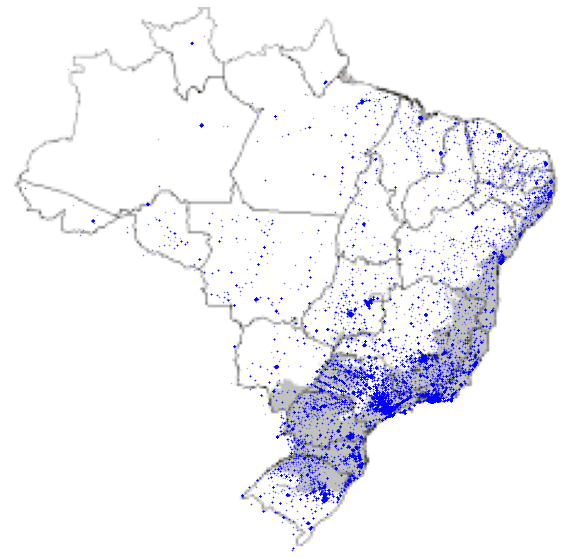

In [158]:
plot_brasil_map(reset_longitude_latitude().drop_duplicates(subset='customer_unique_id'))

Comme on peut le constater, il y a plus de clients dans le sud-est et le sud du pays. On voit également qu'il y a plus de clients dans les villes qui sont des capitales comme São Paulo, Rio de Janeiro, etc..

Il serait maintenant intéressant d'analyser les factures

In [159]:
print(order_items.sample(5))
print(order_items.isna().mean())
print(order_items.groupby('order_id').size().sort_values(ascending=False))

                               order_id  order_item_id  \
35104  4f7e7115e9774e0a45e016fa2cbe4b75              1   
71607  a3631f17471dd636e4886ce7c7f49e04              1   
15794  241d32c9a01951afcb78c68daeaae996              2   
28885  41b77be2144c06162d34e0a18f8f15ce              1   
84836  c0c08274d7ff03824cbf0377b2a9db63              1   

                             product_id                         seller_id  \
35104  f034637ce06bb3a527488a37a59e522d  7e93a43ef30c4f03f38b393420bc753a   
71607  310b40ec41fbfc061e5309006482e68a  527801b552d0077ffd170872eb49683b   
15794  dd72d83b749ec911396ef3337e00b633  4e326052e5dbba8adcd512f3450a307e   
28885  d2f5484cbffe4ca766301b21ab9246dd  36a968b544695394e4e9d7572688598f   
84836  174bd46514622ad40ab32df5c832aaf3  808d4348b916efa08e766ebad39f61eb   

       shipping_limit_date   price  freight_value  
35104  2017-03-24 10:51:33  285.60          16.17  
71607  2018-05-22 02:59:00  519.90          25.24  
15794  2018-02-06 16:51:12   95.

Comme nous avons plus d'un produit par commande, nous devons additionner le prix avec les frais de livraison et aussi obtenir la valeur max de la date limite de livraison pour l'analyse.

              price  freight_value
count  98666.000000   98666.000000
mean     137.754076      22.823562
std      210.645145      21.650909
min        0.850000       0.000000
25%       45.900000      13.850000
50%       86.900000      17.170000
75%      149.900000      24.040000
max    13440.000000    1794.960000


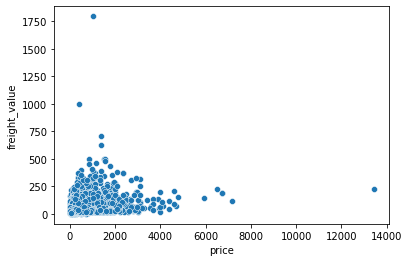

In [160]:
order_items_silver = order_items.groupby('order_id').agg({'shipping_limit_date':max, 'price':sum, 'freight_value':sum }).reset_index()
sns.scatterplot(x='price', y='freight_value',data=order_items_silver)
print(order_items_silver.describe())

On voit que la moyenne du prix des factures est de 137 R$ et 50% des factures ont un coût inférieur à 85$.
On voit que la moyenne des frais de livraison est de 22$ et 50% des frais de livraison ont un coût de 17$

In [161]:
percentil_freight_value = order_items_silver['freight_value'].quantile(0.99)
order_items_silver = order_items_silver[(order_items_silver['price'] <= 5000) & (order_items_silver['freight_value'] <= percentil_freight_value)]
print(order_items_silver.describe())
print(orders.info())

              price  freight_value
count  97679.000000   97679.000000
mean     132.046700      21.423227
std      185.015685      14.133667
min        0.850000       0.000000
25%       45.900000      13.790000
50%       85.000000      17.070000
75%      149.900000      23.700000
max     4690.000000     104.980000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-

In [162]:
columns_timestamp = ['order_delivered_customer_date', 'order_estimated_delivery_date', 'order_purchase_timestamp','order_approved_at',
                     'order_delivered_carrier_date']
                     
for column in columns_timestamp:
    orders[column] = pd.to_datetime(orders[column]) 

orders['diff_delivery_days'] = (orders['order_estimated_delivery_date'] - orders['order_delivered_customer_date']).dt.days
orders.groupby(orders['diff_delivery_days'] < 0).size()

diff_delivery_days
False    91614
True      7827
dtype: int64

On remarque environ 7.82% des commandes ont des frais de livraison sur-estimé

count    96476.000000
mean        10.876881
std         10.183854
min       -189.000000
25%          6.000000
50%         11.000000
75%         16.000000
max        146.000000
Name: diff_delivery_days, dtype: float64


<AxesSubplot:xlabel='diff_delivery_days', ylabel='Count'>

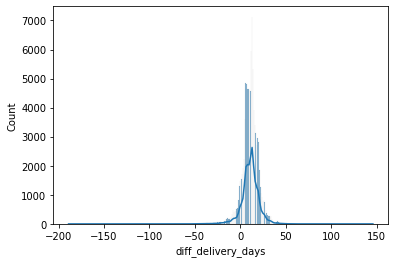

In [163]:
print(orders['diff_delivery_days'].describe())
sns.histplot(x='diff_delivery_days', data=orders, kde=True)

Nous voyons que la différence moyenne entre la livraison estimée et la livraison réelle est de 10 jours, ce qui est un peu élevé. Un autre fait est qu'une commande a été livrée 6 mois plus tard et qu'une autre commande avait une date estimée élevée.

In [164]:
orders[(orders['diff_delivery_days'] > min(orders['diff_delivery_days'])) & (orders['diff_delivery_days'] < max(orders['diff_delivery_days'])) ]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,diff_delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,5.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,17.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,12.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,9.0
...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,10.0
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1.0
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,5.0
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,20.0


Nous allons supprimer la valeur maximale et minimale de la différence.

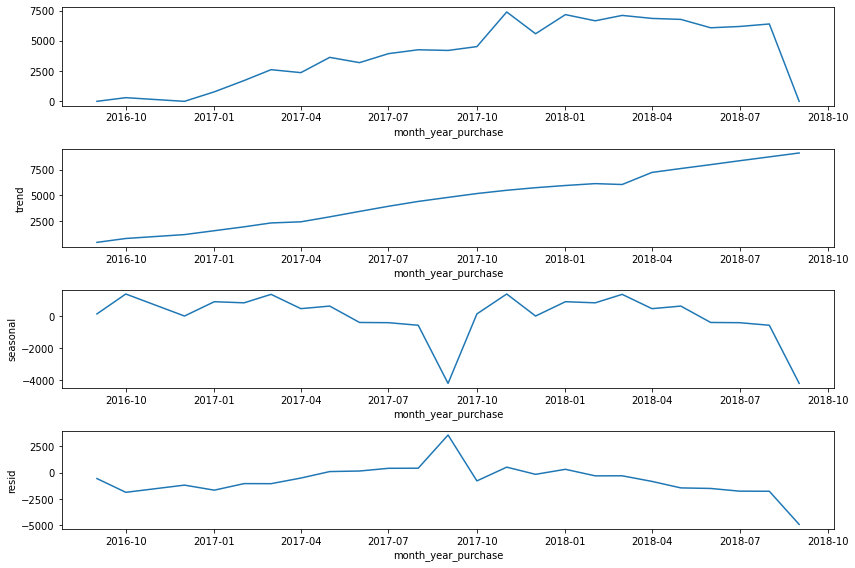

In [165]:
orders_silver = orders.merge(order_items_silver,on='order_id',how='inner')

def plot_ts_decompose(decompose,figsize=(12,8)):
    fig, ax = plt.subplots(4,1,figsize=figsize)
    sns.lineplot(data=decompose.observed, x=decompose.observed.index, y=decompose.observed, ax=ax[0])
    sns.lineplot(data=decompose.trend, x=decompose.trend.index, y=decompose.trend, ax=ax[1])
    sns.lineplot(data=decompose.seasonal, x=decompose.seasonal.index, y=decompose.seasonal, ax=ax[2])
    sns.lineplot(data=decompose.resid, x=decompose.resid.index, y=decompose.resid, ax=ax[3])
    plt.tight_layout()

orders_silver['month_year_purchase'] = orders_silver['order_purchase_timestamp'].dt.to_period('M')
order_purchase_timestamp = orders_silver.groupby('month_year_purchase').size()
order_purchase_timestamp.index = order_purchase_timestamp.index.astype('datetime64[ns]')

decompose = seasonal_decompose(order_purchase_timestamp,model='additive',period=12, extrapolate_trend=12)
plot_ts_decompose(decompose)

Comme nous pouvons le voir, les saisons influent sur les commandes.  En décembre on constate une diminution puis une augmentation en janvier, mars, avril.

Nous remarquons aussi une augmentation constante en 2017-2018

In [166]:
orders_customers = customers.merge(orders_silver, on='customer_id', how='inner')

In [167]:
max_date = max(orders_customers['order_purchase_timestamp']) + datetime.timedelta(days=1) 

rfm_data = orders_customers.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (max_date - x.max()).days,
    'customer_id':'count',
    'price':'sum'
}).reset_index()

rfm_data.columns =['customer_id','recency','frequency','monetary']

print(rfm_data[rfm_data['frequency']>1].shape[0] / rfm_data.shape[0])
print(rfm_data['frequency'].describe())
sns.histplot(x='frequency', data=rfm_data, kde=True)

print(rfm_data['monetary'].describe())
sns.histplot(x='monetary', data=rfm_data, kde=True)

print(rfm_data['recency'].describe())
sns.histplot(x='recency', data=rfm_data, kde=True)

